In [13]:
# imports and constants
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# core settings
N_BINS = 800
LABEL_COL = "nonlinear"
RANDOM_STATE = 42
TRAIN_SIZE = 0.70
VAL_SIZE = 0.15
TEST_SIZE = 0.15

# bin settings
BIN_NARROW = (64, 150)
BIN_WIDE = (64, 799)
REGROWTH_START = 64
MAIN_LOBE = (5, 49)

# training settings
EPOCHS = 120
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
DROPOUT_RATE = 0.3
PATIENCE = 15

cwd_name = os.path.basename(os.getcwd()).lower()
project_root = os.path.dirname(os.getcwd()) if cwd_name == "src" else os.getcwd()
CSV_PATH = os.path.join(project_root, "data", "data.csv")

# reproducibility
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [14]:
# load data and create one fixed split
df = pd.read_csv(CSV_PATH)
X_all = df.iloc[:, :N_BINS].to_numpy(dtype=np.float32)
y = df[LABEL_COL].to_numpy(dtype=np.int64)

indices = np.arange(len(y))
train_idx, temp_idx = train_test_split(
    indices,
    test_size=(VAL_SIZE + TEST_SIZE),
    stratify=y,
    random_state=RANDOM_STATE
)

temp_y = y[temp_idx]
val_ratio_in_temp = VAL_SIZE / (VAL_SIZE + TEST_SIZE)
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=(1 - val_ratio_in_temp),
    stratify=temp_y,
    random_state=RANDOM_STATE
)

print(f"Dataset Shape: X={X_all.shape}, y={y.shape}")
print(f"Split Sizes: train={len(train_idx)}, val={len(val_idx)}, test={len(test_idx)}")

Dataset Shape: X=(10000, 800), y=(10000,)
Split Sizes: train=7000, val=1500, test=1500


In [15]:
# engineered features used by selected dnn experiments
oob = X_all[:, REGROWTH_START:BIN_WIDE[1] + 1]
regrowth = X_all[:, REGROWTH_START:BIN_NARROW[1] + 1]
main_lobe = X_all[:, MAIN_LOBE[0]:MAIN_LOBE[1] + 1]

bin_idx = np.arange(REGROWTH_START, BIN_WIDE[1] + 1, dtype=np.float32)

regrowth_power = regrowth.sum(axis=1)
spectral_slope = np.array([np.polyfit(bin_idx, row, 1)[0] for row in oob], dtype=np.float32)

p = oob / (oob.sum(axis=1, keepdims=True) + 1e-10)
spectral_entropy = -np.sum(p * np.log(p + 1e-10), axis=1)
spectral_flatness = np.exp(np.mean(np.log(oob + 1e-10), axis=1)) / (np.mean(oob, axis=1) + 1e-10)

acpr = regrowth.sum(axis=1) / (main_lobe.sum(axis=1) + 1e-10)
acpr_db = 10.0 * np.log10(np.clip(acpr, 1e-10, None))

oob_mean = oob.mean(axis=1, keepdims=True)
oob_std = oob.std(axis=1, keepdims=True)
spectral_kurtosis = np.mean((oob - oob_mean) ** 4, axis=1) / (oob_std.squeeze() ** 4 + 1e-10)

X_eng = np.column_stack([
    regrowth_power,
    spectral_slope,
    spectral_entropy,
    spectral_flatness,
    acpr_db,
    spectral_kurtosis
]).astype(np.float32)

assert np.isfinite(X_eng).all(), "X_eng contains NaN or inf values"

print(f"Engineered Shape: {X_eng.shape}")

Engineered Shape: (10000, 6)


In [16]:
# model classes and simple data builder
class CNN1D(nn.Module):
    def __init__(self, input_length, dropout_rate=DROPOUT_RATE):
        super().__init__()
        self.n_blocks = self._compute_n_blocks(input_length)

        layers = []
        in_channels = 1
        for _ in range(self.n_blocks):
            layers.extend([
                nn.Conv1d(in_channels, 128, kernel_size=7, padding=3),
                nn.BatchNorm1d(128),
                nn.ReLU(),
                nn.Conv1d(128, 128, kernel_size=5, padding=2),
                nn.BatchNorm1d(128),
                nn.ReLU(),
                nn.MaxPool1d(2),
            ])
            in_channels = 128

        self.conv_stack = nn.Sequential(*layers)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool1d(4),
            nn.Flatten(),
            nn.Linear(128 * 4, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 1),
        )

    @staticmethod
    def _compute_n_blocks(input_length):
        blocks = 0
        spatial = input_length
        while blocks < 5 and (spatial // 2) >= 4:
            blocks += 1
            spatial = spatial // 2
        return max(2, blocks)

    def forward(self, x):
        return self.head(self.conv_stack(x))

class DNN(nn.Module):
    def __init__(self, input_size, dropout_rate=DROPOUT_RATE):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.net(x)

class EarlyStopping:
    def __init__(self, patience, path="best_model.pt"):
        self.patience = patience
        self.path = path
        self.best_loss = np.inf
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        return self.early_stop

    def load_best(self, model):
        model.load_state_dict(torch.load(self.path, map_location="cpu"))
        return model

def build_loaders(X_raw, X_eng, use_engineered, model_type):
    # fit scalers on train only
    raw_scaler = StandardScaler()
    X_train_raw = raw_scaler.fit_transform(X_raw[train_idx])
    X_val_raw = raw_scaler.transform(X_raw[val_idx])
    X_test_raw = raw_scaler.transform(X_raw[test_idx])

    if model_type == "CNN":
        X_train = X_train_raw[:, np.newaxis, :]
        X_val = X_val_raw[:, np.newaxis, :]
        X_test = X_test_raw[:, np.newaxis, :]
    else:
        if use_engineered:
            eng_scaler = StandardScaler()
            X_train_eng = eng_scaler.fit_transform(X_eng[train_idx])
            X_val_eng = eng_scaler.transform(X_eng[val_idx])
            X_test_eng = eng_scaler.transform(X_eng[test_idx])
            X_train = np.hstack([X_train_raw, X_train_eng])
            X_val = np.hstack([X_val_raw, X_val_eng])
            X_test = np.hstack([X_test_raw, X_test_eng])
        else:
            X_train = X_train_raw
            X_val = X_val_raw
            X_test = X_test_raw

    y_train = y[train_idx].astype(np.float32).reshape(-1, 1)
    y_val = y[val_idx].astype(np.float32).reshape(-1, 1)
    y_test = y[test_idx].astype(np.float32).reshape(-1, 1)

    train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
    val_ds = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32))
    test_ds = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
    return train_loader, val_loader, test_loader

In [ ]:
# experiment loop: train cnn and dnn variants, then evaluate on test
experiments = [
    {"id": 1, "model_type": "CNN", "bins": BIN_WIDE, "use_engineered": False},
    {"id": 2, "model_type": "CNN", "bins": BIN_NARROW, "use_engineered": False},
    {"id": 3, "model_type": "DNN", "bins": BIN_WIDE, "use_engineered": False},
    {"id": 4, "model_type": "DNN", "bins": BIN_WIDE, "use_engineered": True},
    {"id": 5, "model_type": "DNN", "bins": BIN_NARROW, "use_engineered": False},
    {"id": 6, "model_type": "DNN", "bins": BIN_NARROW, "use_engineered": True},
]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.BCEWithLogitsLoss()
results = []
roc_artifacts = {}

for exp in experiments:
    print(f"\nExp {exp['id']} Start | {exp['model_type']} | Bins={exp['bins'][0]}-{exp['bins'][1]} | Engineered={exp['use_engineered']}")

    b0, b1 = exp["bins"]
    X_raw = X_all[:, b0:b1 + 1]
    train_loader, val_loader, test_loader = build_loaders(
        X_raw=X_raw,
        X_eng=X_eng,
        use_engineered=exp["use_engineered"],
        model_type=exp["model_type"],
    )

    sample_x, _ = next(iter(train_loader))
    if exp["model_type"] == "CNN":
        model = CNN1D(input_length=X_raw.shape[1], dropout_rate=DROPOUT_RATE).to(device)
        n_input_features = int(sample_x.shape[-1])
        if exp["id"] in [1, 2]:
            assert sample_x.ndim == 3 and sample_x.shape[1] == 1, "CNN input must be [batch, 1, features]"
    else:
        model = DNN(input_size=int(sample_x.shape[1]), dropout_rate=DROPOUT_RATE).to(device)
        n_input_features = int(sample_x.shape[1])

    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)
    best_path = f"best_model_exp{exp['id']}.pt"
    early_stopping = EarlyStopping(patience=PATIENCE, path=best_path)

    for _ in range(EPOCHS):
        # train
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        # validate
        model.eval()
        val_running_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                val_running_loss += criterion(logits, yb).item() * xb.size(0)

        val_loss = val_running_loss / len(val_loader.dataset)
        scheduler.step(val_loss)
        if early_stopping(val_loss, model):
            break

    early_stopping.load_best(model)
    if os.path.exists(best_path):
        os.remove(best_path)

    # train accuracy at fixed threshold 0.5
    train_proba = []
    train_true = []
    model.eval()
    with torch.no_grad():
        for xb, yb in train_loader:
            xb = xb.to(device)
            logits = model(xb)
            train_proba.append(torch.sigmoid(logits).cpu().numpy())
            train_true.append(yb.cpu().numpy())
    y_train_proba = np.vstack(train_proba).ravel()
    y_train_true = np.vstack(train_true).ravel().astype(int)
    train_accuracy = accuracy_score(y_train_true, (y_train_proba >= 0.5).astype(int))

    # test probabilities
    model.eval()
    test_proba = []
    with torch.no_grad():
        for xb, _ in test_loader:
            xb = xb.to(device)
            logits = model(xb)
            test_proba.append(torch.sigmoid(logits).cpu().numpy())
    y_proba = np.vstack(test_proba).ravel()
    y_true = y[test_idx].astype(int)

    # auxiliary best-F1 threshold
    threshold_candidates = np.unique(np.round(y_proba, 6))
    best_f1_threshold, best_f1_aux = 0.5, 0.0
    for t in threshold_candidates:
        y_hat_t = (y_proba >= t).astype(int)
        f1_t = f1_score(y_true, y_hat_t, zero_division=0)
        if f1_t > best_f1_aux:
            best_f1_aux, best_f1_threshold = f1_t, float(t)

    # main metrics at fixed threshold 0.5
    y_pred = (y_proba >= 0.5).astype(int)
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_proba)

    results.append({
        "experiment_id": exp["id"],
        "model_type": exp["model_type"],
        "bin_range": f"{b0}-{b1}",
        "use_engineered": exp["use_engineered"],
        "n_input_features": n_input_features,
        "train_accuracy": float(train_accuracy),
        "threshold_main": 0.5,
        "best_f1_threshold": float(best_f1_threshold),
        "best_f1_at_best_threshold": float(best_f1_aux),
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "auc_roc": float(auc),
    })

    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_artifacts[exp["id"]] = {"fpr": fpr, "tpr": tpr, "auc": auc}

    print(
        f"Exp {exp['id']} Train/Test | TrainAcc={train_accuracy:.4f} | Thr=0.5 Acc={accuracy:.4f} | "
        f"Prec={precision:.4f} | Rec={recall:.4f} | F1={f1:.4f} | AUC={auc:.4f} | Best_F1_Thr={best_f1_threshold:.4f}"
    )


Exp 1 Start | CNN | Bins=64-799 | Engineered=False
Exp 1 Test | Thr=0.5 Acc=0.4880 | Prec=0.4907 | Rec=0.6360 | F1=0.5540 | AUC=0.4862 | Best_F1_Thr=0.4398

Exp 2 Start | CNN | Bins=64-150 | Engineered=False
Exp 2 Test | Thr=0.5 Acc=0.4307 | Prec=0.3855 | Rec=0.2333 | F1=0.2907 | AUC=0.3997 | Best_F1_Thr=0.4393

Exp 3 Start | DNN | Bins=64-799 | Engineered=False
Exp 3 Test | Thr=0.5 Acc=0.4153 | Prec=0.4129 | Rec=0.4013 | F1=0.4070 | AUC=0.3811 | Best_F1_Thr=0.4003

Exp 4 Start | DNN | Bins=64-799 | Engineered=True
Exp 4 Test | Thr=0.5 Acc=0.4127 | Prec=0.4192 | Rec=0.4533 | F1=0.4356 | AUC=0.3790 | Best_F1_Thr=0.4231

Exp 5 Start | DNN | Bins=64-150 | Engineered=False
Exp 5 Test | Thr=0.5 Acc=0.4760 | Prec=0.4757 | Rec=0.4707 | F1=0.4732 | AUC=0.4583 | Best_F1_Thr=0.3501

Exp 6 Start | DNN | Bins=64-150 | Engineered=True
Exp 6 Test | Thr=0.5 Acc=0.4707 | Prec=0.4749 | Rec=0.5560 | F1=0.5123 | AUC=0.4520 | Best_F1_Thr=0.3762


,experiment_id,model_type,bin_range,use_engineered,n_input_features,threshold_main,best_f1_threshold,best_f1_at_best_threshold,accuracy,precision,recall,f1,auc_roc
0,1,CNN,64-799,False,736,0.5,0.439807,0.666667,0.488000,0.490741,0.636000,0.554007,0.486179
1,5,DNN,64-150,False,87,0.5,0.350120,0.666963,0.476000,0.475741,0.470667,0.473190,0.458324
2,6,DNN,64-150,True,93,0.5,0.376181,0.666667,0.470667,0.474943,0.556000,0.512285,0.452044
3,2,CNN,64-150,False,87,0.5,0.439281,0.666667,0.430667,0.385463,0.233333,0.290698,0.399662
4,3,DNN,64-799,False,736,0.5,0.400308,0.666074,0.415333,0.412894,0.401333,0.407032,0.381108
5,4,DNN,64-799,True,742,0.5,0.423067,0.666667,0.412667,0.419236,0.453333,0.435618,0.378974


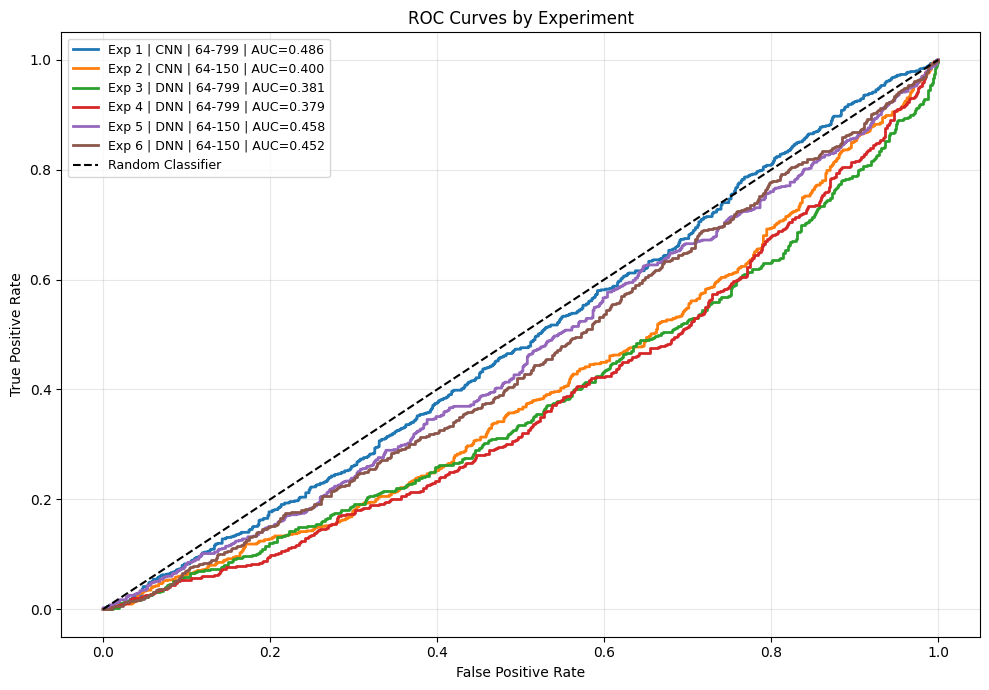

In [18]:
# compact results table and roc-only visualization
results_df = pd.DataFrame(results).sort_values("auc_roc", ascending=False).reset_index(drop=True)
display(results_df)

plt.figure(figsize=(10, 7))
for exp in experiments:
    art = roc_artifacts[exp["id"]]
    label = f"Exp {exp['id']} | {exp['model_type']} | {exp['bins'][0]}-{exp['bins'][1]} | AUC={art['auc']:.3f}"
    plt.plot(art["fpr"], art["tpr"], linewidth=2, label=label)

plt.plot([0, 1], [0, 1], "k--", linewidth=1.5, label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves by Experiment")
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()